In [ ]:
#Programming assignment
In this exercise, we will practice network analysis and spatial accessibility modelling. Our overall goal is to analyze healthcare accessibility by conducting a two-step floating catchment area analysis in Helsinki Region. We will calculate travel time-based catchment areas by public transport (30 minutes threshold) from healthcare facilities (Health stations, University hospitals and City hospitals) located in the area to population grid cells (250 meter resolution) in the Helsinki Region. Based on the population information and the number of physicians at given hospital (simulated --> not real), we can calculate an accessibility index based on 2SFCA method. The end result should look something like following:

"Healthcare accessibility map in Helsinki Region

The main point in this Exercise is to practice how to do accessibility analysis in Python, and use it for a practical health-related research question. Similar approaches can be used for many different applications that require understanding supply and demand of some kind of service (can be e.g. commercial application as well).

Start your exercise in CSC Notebooks
Before you can start programming, you need to launch the CSC Notebook instance and clone your Exercise repository there. If you need help with this, read the documentation on the course site.

Hints
If there are general questions arising from this exercise, we will add hints to the course website under Exercise 2 description.

Input data for the exercise
We will use only openly available data sources for this exercise, listed below.

Healthcare facilities and number of physicians
We will use the real locations of healthcare facilities in Helsinki Region (based on data from Palvelukartta) and simulated data about the number of doctors working in them. The distribution of the number of doctors working in different facilities looks like this (the size of the bubble corresponds the number of physicians): The proportion of doctors in different Helsinki Region health facilities

Notice that this data is not real and it has been simulated based on openly available data/information and has many assumptions (e.g. that the number of doctors in cities reflect the average of whole Finland which is 3.8 doctors per 1000 inhabitants). The physicians are allocated to different facilities based on relative number of health-related employees working at different postal code areas (again a big assumption). These steps have been taken to make the data a bit more realistic, but they cannot be considered to reflect reality. If you are interested to see the details of how the data was produced based on open data, check this notebook.

Population distribution
The population data that we will use in this exercise is openly available from HSY. The data is from 2019 and it has been cleaned, so it is ready for you to use. The column pop_cnt contains information about the number of inhabitants in given grid cell (note: the original column name is "ASUKKAITA"). The population distribution in Helsinki looks like following:

Population distribution

Street network and GTFS
For conducting the accessibility analysis, we will use OpenStreetMap and GTFS data using r5py library.

In [5]:

#Helper functions
The following helper functions will be used in the exercise for parsing catchment area information for hospitals. Execute this cell before starting to work on the exercise.

def prepare_network(osm_fp, gtfs_fp):
    """
    Helper function to create a routable network for r5py based on OpenStreetMap data and GTFS data.
    
    Parameters
    ----------
    
    osm_fp : str
    
        Filepath to the OpenStreetMap PBF file (*.osm.pbf).
        
    gtfs_fp : str | list
    
        Filepath to the GTFS zip-file, or alternatively a list of multiple filepaths to GTFS Zipfiles.
        
    """
    
    from r5py import TransportNetwork

    if isinstance(gtfs_fp, str):
        gtfs_fp = [gtfs_fp]
    elif isinstance(gtfs_fp, list):
        # Check that the inputs are valid
        for item in gtfs_fp:
            assert isinstance(item, str), f"All objects in 'gtfs_fp' list should be filepath strings. Got '{type(item)}'."

    # Build network
    net = TransportNetwork(osm_fp,  gtfs_fp)
    return net

def make_bubble_map(gdf, radius_column, column=None, cmap="hsv", tiles="CartoDB darkmatter"):
    """
    Helper function to generate bubble map from input Point dataset.
    
    Parameters
    ----------
    
    gdf : gpd.GeoDataFrame
        
        The GeoDataFrame that should contain points.
    
    radius_column : str
        
        Name for the column which determines the size of the bubble (required).
    
    column : str
    
        Name for the column which will be used to determine a color of the bubble (optional).
    
    cmap : str
    
        Colormap which will be determining the colors if `column` variable is used.
    
    tiles : str
    
        Background map style. By default, plots using a dark background (CartoDB darkmatter)
    
    
    """
    import numpy as np
    
    # Generate bubble map
    m = gdf.explore(column=column, cmap=cmap,
                    
                    # Generate Bubbles based on given radius column
                    style_kwds={"style_function": lambda x: {
                            "radius": np.sqrt(x["properties"][radius_column])*0.7,
                            "stroke": True,  
                            "color": "gray",
                            "weight": 1}
                            },
                    # Background map style
                    tiles="CartoDB darkmatter",
                   )
    return m

def parse_id_of_the_closest_facility(travel_time_matrix, origin_column="from_id", destination_column="to_id", distance_column="travel_time"):
    """
    A helper function to define catchment areas for given facilities. The function will find out which origin is closest to the given destinations based on travel time. 
    The 'id' of the origins will be stored to a new column called "facility_id". 
    
    Parameters
    ----------
    
    travel_time_matrix : pd.DataFrame
    
        DataFrame containing the data with travel time information.
     
    origin_column : str
    
        The name of the column containing origin ids (typically 'from_id' column).
    
    destination_column : str
    
        The name of the column containing destination ids (typically 'to_id' column).
    
    distance_column : str
    
        The name of the column containing the travel times (or other distance information).
    """
    # Set the origin as index (i.e. in our case the column name of the id representing hospitals in the matrix)
    travel_time_matrix = travel_time_matrix.set_index(origin_column)

    # Find the from_id of the closest facility based on travel time
    closest_facility = travel_time_matrix.groupby(destination_column)[distance_column].idxmin(skipna=True).reset_index()

    # Rename the column from "travel_time" to more intuitive one
    closest_facility = closest_facility.rename(columns={"travel_time": "facility_id"})
    
    return closest_facility

def parse_travel_time_to_the_closest_facility(travel_time_matrix, origin_column="from_id", destination_column="to_id", distance_column="travel_time"):
    """
    A helper function to parse the travel times for closest facilities. The function will find out which origin is closest 
    to the given destinations based on travel time and returns travel times for the closest facilities. 
    
    Parameters
    ----------
    
    travel_time_matrix : pd.DataFrame
    
        DataFrame containing the data with travel time information.
     
    origin_column : str
    
        The name of the column containing origin ids (typically 'from_id' column).
    
    destination_column : str
    
        The name of the column containing destination ids (typically 'to_id' column).
    
    distance_column : str
    
        The name of the column containing the travel times (or other distance information).
    """
    
    # Find the from_id of the closest facility based on travel time
    closest_facility = travel_time_matrix.groupby(destination_column)[distance_column].min().reset_index()

    return closest_facility

def calculate_2SFCA(travel_time_matrix, ppr_gdf, population_grid_gdf):
    """
    A helper function to calculate accessibility index based on Two-step Floating Catchment Area method. 
    
    Parameters
    ----------
    
    travel_time_matrix : pd.DataFrame
    
        DataFrame containing the data with travel time information.
     
    ppr_gdf : gpd.GeoDataFrame
    
        A GeoDataFrame containing the data about provider-to-population ratio for each hospital.
    
    population_grid_gdf : str
    
        A GeoDataFrame containing the data about the number of inhabitants living in the Helsinki Region. The data should be 
        a Polygon grid with 250 meter resolution. 
    
    """
    
    # Remove those connections that were not reachable within given time
    filtered = travel_time_matrix.loc[~travel_time_matrix["travel_time"].isnull()]

    # Join the data to grid
    join = population_grid_gdf.merge(filtered, left_on="id", right_on="from_id")

    # Container for the results
    final_results = []

    # Group the data by origins and see how many hospitals are within reach
    catchments = join.groupby("from_id")

    for idx, catchment in catchments:

        # Merge the information with the hospitals
        hospitals_within = catchment.merge(ppr_gdf[["ppr", "facility_id", "name_en"]], left_on="to_id", right_on="facility_id")

        # What is the sum of PPRs for given pop grid code
        two_step_index = hospitals_within["ppr"].sum()

        # Fetch the geometry
        geom = catchment.iloc[0]["geometry"]

        # Update the data
        final_results.append({"geometry": geom, "accessibility": two_step_index})

    gdf = gpd.GeoDataFrame(final_results, geometry="geometry", crs="epsg:4326")
    return gdf

In [2]:
!pip install geopandas pandas numpy matplotlib shapely pyproj fiona

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

In [35]:
os.makedirs("outputs", exist_ok=True)

In [36]:
ffile_path = "hospital_data.geojson"


In [37]:
population_path = r"C:\Users\siddi\Downloads\exercise-2-anassmo7-main\exercise-2-anassmo7-main\data\population_grid_hsy.geojson"

hospital_path = r"C:\Users\siddi\Downloads\exercise-2-anassmo7-main\exercise-2-anassmo7-main\data\hospital_data.geojson"

In [38]:
population = gpd.read_file(population_path)
facilities = gpd.read_file(hospital_path)

In [39]:
print(population.head())
print(facilities.head())

print(population.columns)
print(facilities.columns)

   id  pop_cnt                                           geometry
0   0        5  POLYGON ((24.50287 60.28562, 24.50284 60.28787...
1   1        8  POLYGON ((24.50311 60.26992, 24.50308 60.27216...
2   2        5  POLYGON ((24.50315 60.26767, 24.50311 60.26992...
3   3       12  POLYGON ((24.50328 60.25870, 24.50325 60.26094...
4   4        5  POLYGON ((24.50682 60.32378, 24.50678 60.32603...
   id                    name_fi                    name_en   facility_type  \
0   0   Kivenlahden terveysasema   Kivenlahti Health Centre  health-station   
1   1      Samarian terveysasema      Samaria Health Centre  health-station   
2   2  Espoonlahden terveysasema  Espoonlahti Health Centre  health-station   
3   3        Soukan terveysasema       Soukka Health Center  health-station   
4   4            Espoon sairaala             Espoo Hospital   city-hospital   

  postal_code   city  physician_cnt                   geometry  
0       02320  Espoo             13  POINT (24.63564 60.15481)  

In [40]:
population = population.rename(columns={
    "id": "grid_id",
    "pop_cnt": "population"
})

facilities = facilities.rename(columns={
    "id": "facility_id",
    "physician_cnt": "physicians"
})

In [41]:
population = population.to_crs(epsg=3067)
facilities = facilities.to_crs(epsg=3067)

In [42]:
population["geometry"] = population.geometry.centroid

In [43]:
print(population.isna().sum())
print(facilities.isna().sum())

grid_id       0
population    0
geometry      0
dtype: int64
facility_id      0
name_fi          0
name_en          3
facility_type    0
postal_code      0
city             0
physicians       0
geometry         0
dtype: int64


In [44]:
population["population"] = population["population"].fillna(0)
facilities["physicians"] = facilities["physicians"].fillna(1)

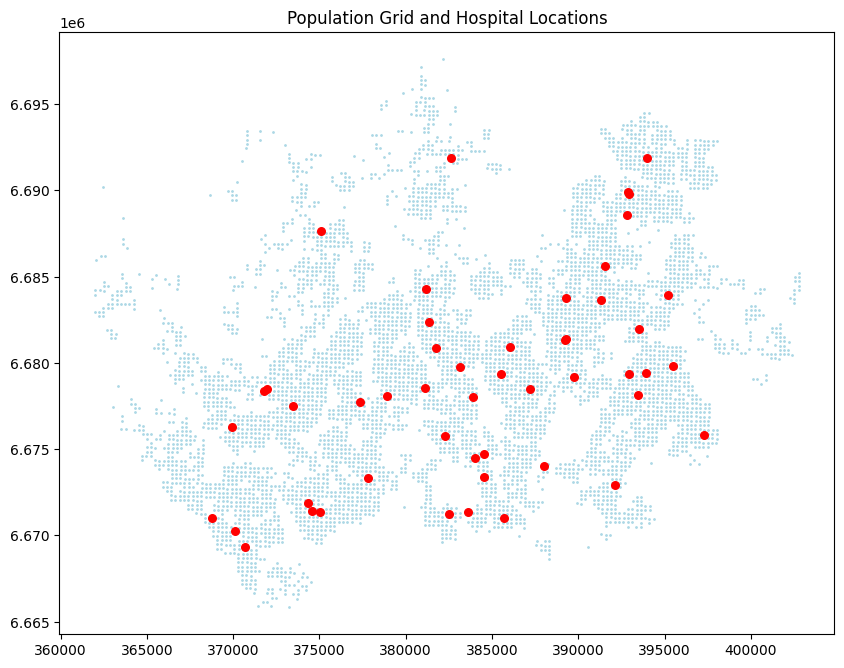

In [45]:
fig, ax = plt.subplots(figsize=(10, 10))

population.plot(
    ax=ax,
    markersize=1,
    color="lightblue"
)

facilities.plot(
    ax=ax,
    color="red",
    markersize=30
)

plt.title("Population Grid and Hospital Locations")
plt.show()